In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import os
import sys
from scipy.signal import resample_poly

In [2]:
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

These files consists of functions required to process the data

In [3]:
import src.data_loader
import src.preprocess_data
import src.visualisation
import yaml

In [4]:
CONFIG_PATH = Path("../config.yaml")

with open(CONFIG_PATH, "r") as file:
    config = yaml.safe_load(file)

In [5]:
data_dir = Path(config["data_dir"])
dir_file = config["sessions"]

# Exploring the data in the Step Logger sensor

In [ ]:
Sensor_Logger_folder = config["sensor_logger"]["folder"]

file_prefix = config["sensor_logger"]["file_prefix"]

sensor_logger_recordings_trimmed_dir = (
    Path(Sensor_Logger_folder) /
    config["sensor_logger"]["trimmed_folder"]
)

trimmed_sensor_logger_file_prefix = (
    config["sensor_logger"]["trimmed_file_prefix"]
)

The length of the df 79046


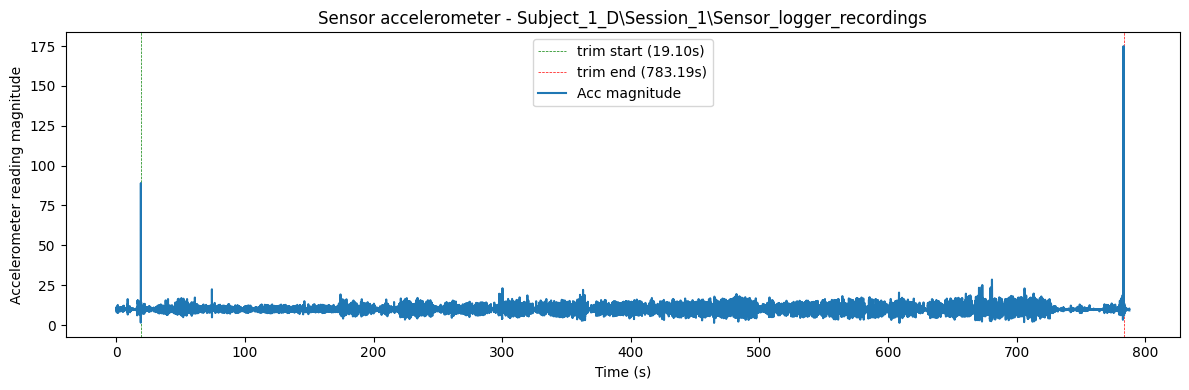

The length of the df 79310


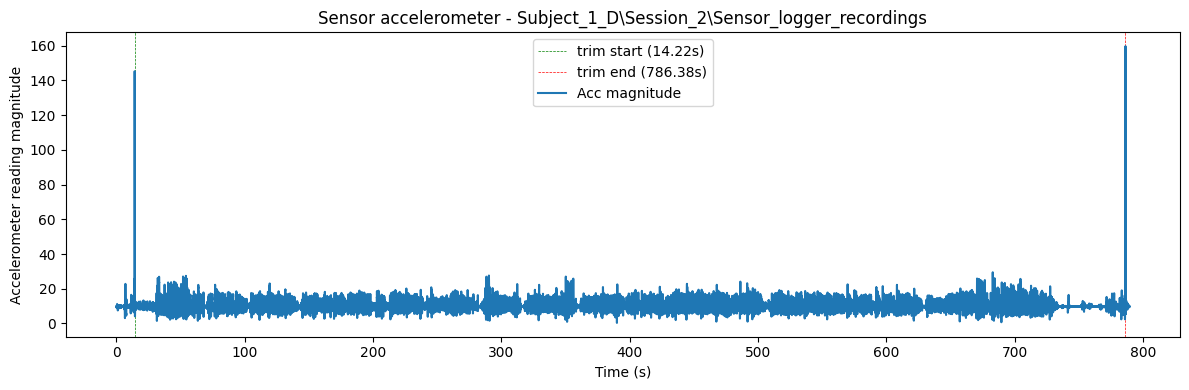

The length of the df 85625


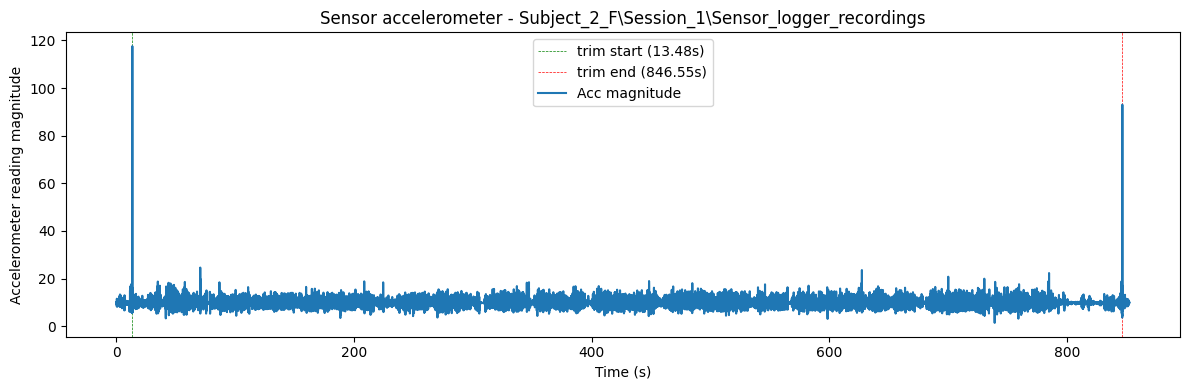

The length of the df 84703


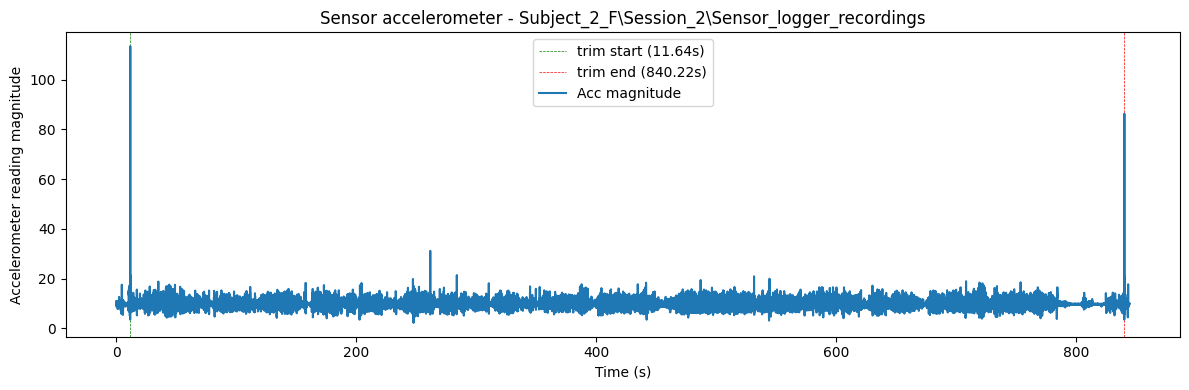

The length of the df 86530


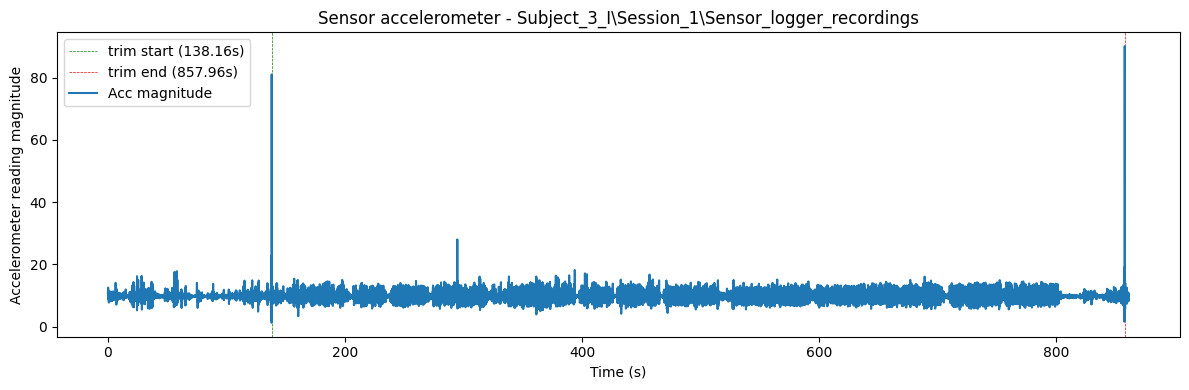

The length of the df 75668


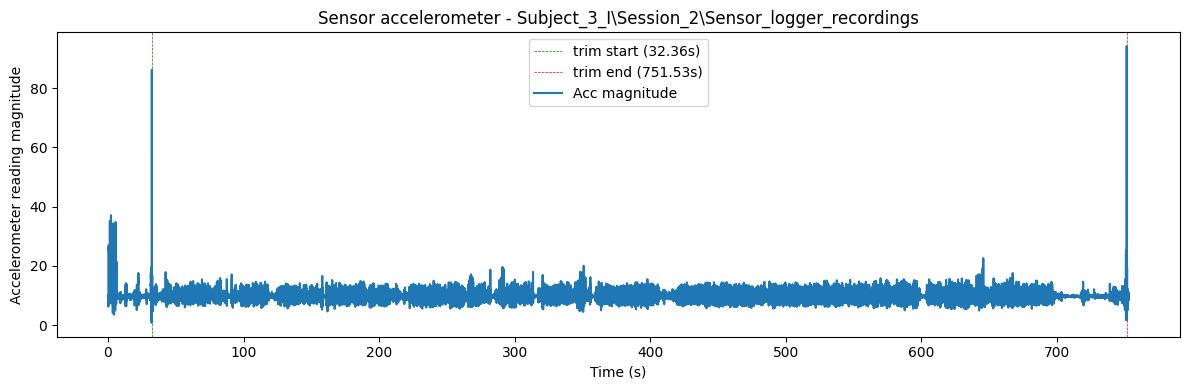

In [ ]:
for i in range(len(dir_file)):
    
    file_path = os.path.join(data_dir, dir_file[i], file_prefix)
    df = src.data_loader.load_sensor_data(file_path)
    print(f"The length of the df", len(df))
    df["time_s"] = df["time"] / 1e9
    df["time_s"] = (df["time_s"] - df["time_s"].iloc[0]).round(4)
    time_start, time_end = src.preprocess_data.get_start_end_time(df, 20000)
    acc_mag = np.sqrt(df["x"]**2 + df["y"]**2 + df["z"]**2)
    src.visualisation.plot_acceleration_magnitude_with_lines(df,time_start, time_end, acc_mag, dir_file[i],"time_s")

Trimming files of the sensor logger signal recordings and saving them in a folder

In [ ]:
for i in range(len(dir_file)):
        file_path = os.path.join(data_dir, dir_file[i], file_prefix)
        df = src.data_loader.load_sensor_data(file_path)
        print(f"The length of the df", len(df))
        df["time_s"] = df["time"] / 1e9
        df["time_s"] = (df["time_s"] - df["time_s"].iloc[0]).round(4)
        time_start, time_end = src.preprocess_data.get_start_end_time(df, 20000)

        for files in Path(os.path.join(data_dir, dir_file[i])).glob("*.csv"):
            filename = files.stem.split("\\")[-1]

            if filename in ["Annotation", "Metadata"]:
                continue
            
            df = src.data_loader.load_sensor_data(files)
            df["time_s"] = df["time"] / 1e9
            df["time_s"] = (df["time_s"] - df["time_s"].iloc[0]).round(4)
            df = src.preprocess_data.trim_signal_with_time(df,time_start,time_end)
            
            print(f"{len(df)} rows kept, "
            f"{df['time_s'].iloc[0]:.2f}s -> {df['time_s'].iloc[-1]:.2f}s")

            OUT_DIR = Path(os.path.join(data_dir, dir_file[i], "trimmed"))
            OUT_DIR.mkdir(exist_ok=True)

            df.to_csv(OUT_DIR / f"trimmed_{filename}.csv", index=False)

            print(f"Saved {OUT_DIR / f"trimmed_{filename}.csv"} trimmed files to {OUT_DIR}")

print("Trimmed all the files and saved to the trimmed folder")

The Next steps:
1. Mapping the checkpoints to both the wrist sensors and the android sensors using acceleration magnitude
2. Mapping the Timestamp in Xsens and Android Phone sensor recording and then mapping the events according to the step logger accurately
3. Converting the trimmed Sensor Logger Data  data to 60 Hz so that we can map it directly to the XSens data.

In [ ]:
for i in range(len(dir_file)):

    # Load the Sensor Logger data
    sensor_logger_path = os.path.join(data_dir, dir_file[i], sensor_logger_recordings_trimmed_dir, f"{trimmed_sensor_logger_file_prefix}.csv")
    sensor_logger_df = src.data_loader.load_sensor_data(sensor_logger_path) 

    resampled_df = src.preprocess_data.downsample_with_nanos(sensor_logger_df, time_col="time", signal_cols=["z", "y", "x"])

    OUT_DIR = Path(os.path.join(data_dir, dir_file[i], Sensor_Logger_folder, config["sensor_logger"]["trimmed_60Hz_folder"]))
    OUT_DIR.mkdir(exist_ok=True)

    resampled_df.to_csv(
        OUT_DIR / f"{trimmed_sensor_logger_file_prefix}_60Hz.csv",
        index=False
    )

    print(f"Saved {len(sensor_logger_df)} trimmed files to {OUT_DIR}")


# Trimming the XSens Data, using the peaks to trim.

Since Sensor logger is also trimmed at peaks and is downsampled at 60Hz now so we can take the 0th timestamp of Sensor logger recording and add the timestamp to XSens as in Physically the peak happend at the same time stamp for both harware.

In [ ]:
def process_xsens_session(
    data_dir: Path,
    file_prefix: str,
    sensor_logger_timestamp: np.int64,
    output_folder: str
) -> None:

    sensor_map = {}

    for file in data_dir.glob("*.txt"):
        device_id = file.name.split("_")[-1].rsplit(".", 1)[0]
        sensor_map[device_id] = device_id

    sensors = {}

    for device_id, body_part in sensor_map.items():

        file_path = data_dir / f"{file_prefix}{device_id}.txt"

        df = src.data_loader.load_xsens_file(file_path)

        sensors[body_part] = df

    # Check sensor consistency
    lengths = {
        body_part: len(df)
        for body_part, df in sensors.items()
    }

    packet_counter_ranges = {
        body_part: (
            df["PacketCounter"].iloc[0],
            df["PacketCounter"].iloc[-1]
        )
        for body_part, df in sensors.items()
    }

    print(
        "Row counts match across sensors:",
        len(set(lengths.values())) == 1
    )

    print(
        "PacketCounter ranges match across sensors:",
        len(set(packet_counter_ranges.values())) == 1
    )

    # Use right wrist as reference sensor
    reference_sensor = "10B41710"

    row_start, row_end = src.preprocess_data.get_start_end_Magnitude(
        sensors[reference_sensor]
    )

    trimmed = {
        body_part: src.preprocess_data.trim_signal_with_idx(
            df,
            row_start,
            row_end
        )
        for body_part, df in sensors.items()
    }

    # Add timestamps
    for body_part in trimmed:

        trimmed[body_part] = src.preprocess_data.add_timestamp(
            trimmed[body_part],
            sensor_logger_timestamp
        )

        df = trimmed[body_part]

        print(
            f"{body_part:12s}: {len(df)} rows kept, "
            f"{df['Normalized_time_secs'].iloc[0]:.2f}s -> "
            f"{df['Normalized_time_secs'].iloc[-1]:.2f}s"
        )

    # Save trimmed data
    output_dir = data_dir.parent / output_folder
    output_dir.mkdir(parents=True, exist_ok=True)

    for body_part, df in trimmed.items():

        df.to_csv(
            output_dir / f"trimmed_{body_part}.csv",
            index=False
        )

    print(
        f"Saved {len(trimmed)} trimmed files to {output_dir}"
    )

In [ ]:
for session in dir_file:

    xsens_dir = data_dir / session / config["xsens_folder"]["raw"]

    sensor_logger_path = (
        data_dir
        / session
        / Sensor_Logger_folder
        / config["sensor_logger"]["trimmed_60Hz_folder"]
        / f"{trimmed_sensor_logger_file_prefix}.csv"
    )

    sensor_logger_df = src.data_loader.load_sensor_data(
        sensor_logger_path
    )

    sensor_logger_timestamp = sensor_logger_df["time"].iloc[0]

    src.preprocess_data.process_xsens_session(
        xsens_dir,
        config["xsens_folder"]["file_prefix"] + "_",
        sensor_logger_timestamp,
        config["xsens_folder"]["trimmed_folder"]
    )

lenth of the right sensor 45848
Starting and ending seconds of XSens 0.0  to  764.116667
Index(['time', 'Checkpoint', 'zeros_1', 'zeros_2', 'zeros_3', 'time_s'], dtype='str')
Index(['z', 'y', 'x', 'time', 'Normalized_time_secs'], dtype='str')
lenth of the sensor logger 46005
Starting and ending seconds of Sensor Logger 0.0  to  766.733333


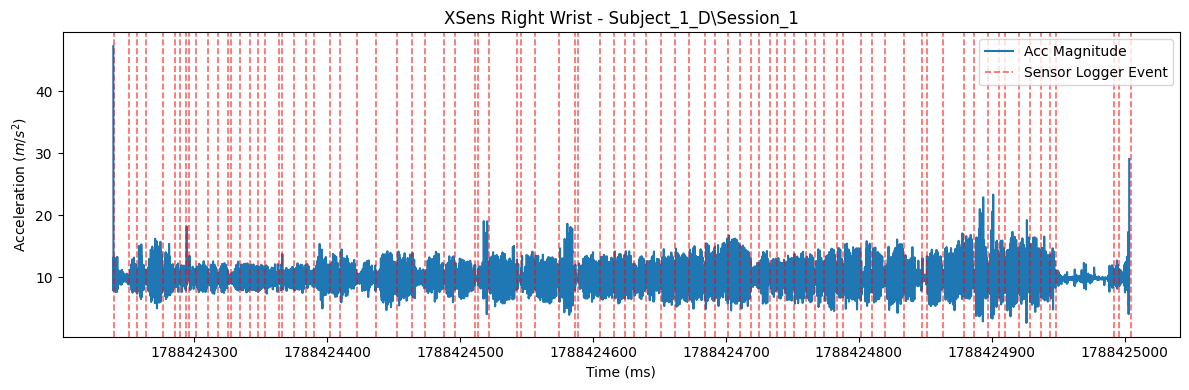

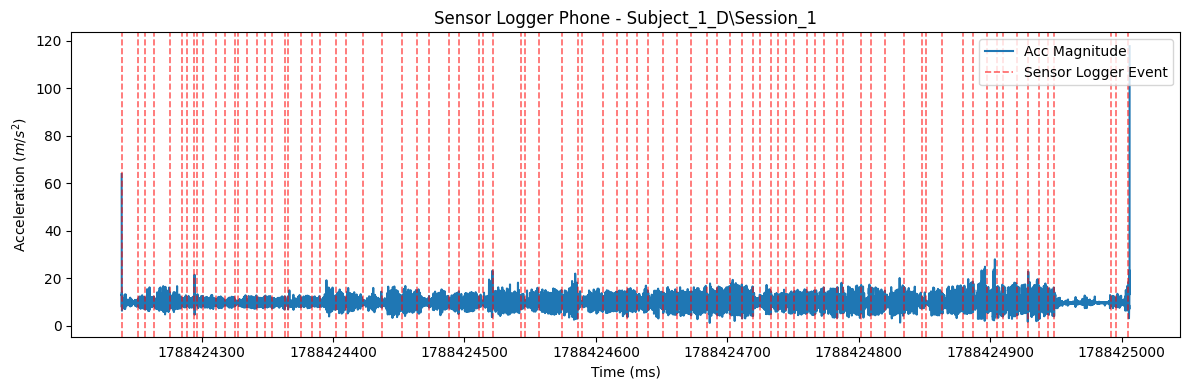

lenth of the right sensor 46331
Starting and ending seconds of XSens 0.0  to  772.166667
Index(['time', 'Checkpoint', 'zeros_1', 'zeros_2', 'zeros_3', 'time_s'], dtype='str')
Index(['z', 'y', 'x', 'time', 'Normalized_time_secs'], dtype='str')
lenth of the sensor logger 46548
Starting and ending seconds of Sensor Logger 0.0  to  775.783333


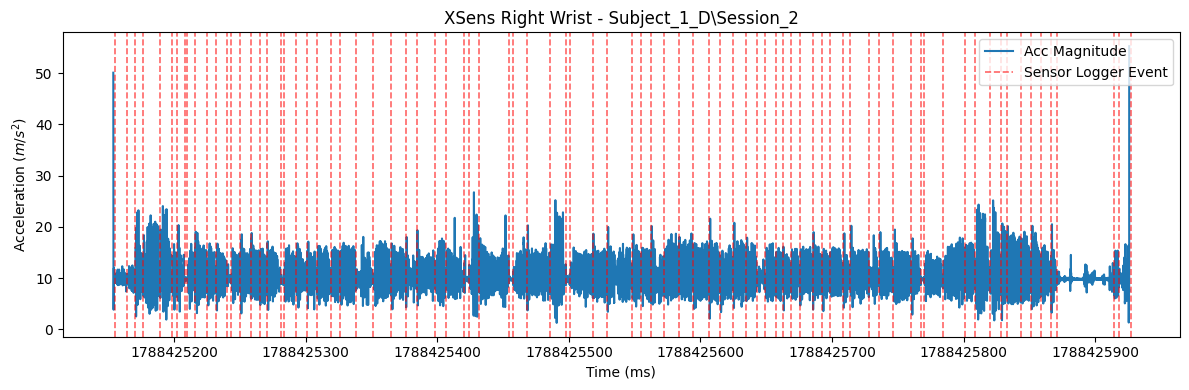

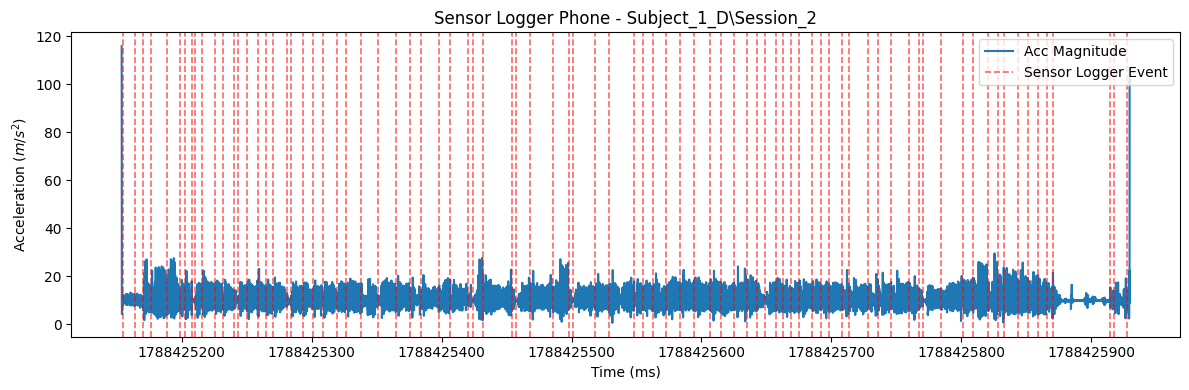

lenth of the right sensor 49985
Starting and ending seconds of XSens 0.0  to  833.066667
Index(['time', 'Checkpoint', 'zeros_1', 'zeros_2', 'zeros_3', 'time_s'], dtype='str')
Index(['z', 'y', 'x', 'time', 'Normalized_time_secs'], dtype='str')
lenth of the sensor logger 50210
Starting and ending seconds of Sensor Logger 0.0  to  836.816667


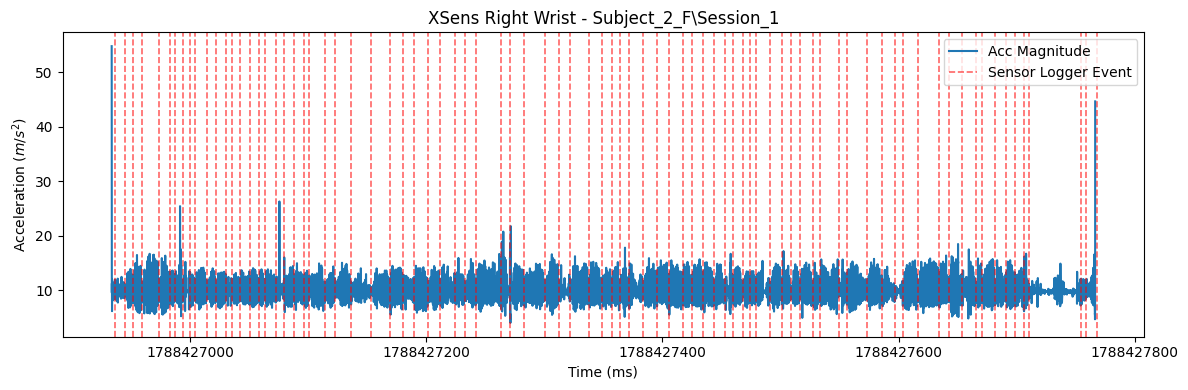

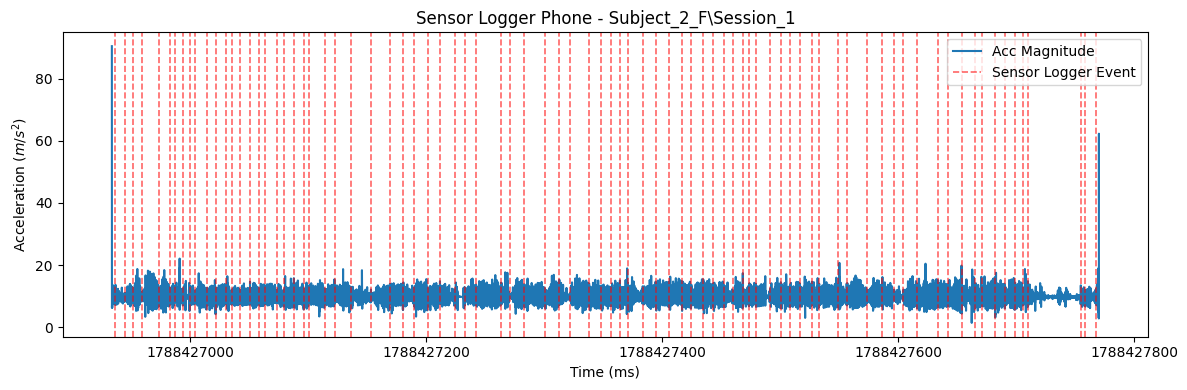

lenth of the right sensor 49718
Starting and ending seconds of XSens 0.0  to  828.616667
Index(['time', 'Checkpoint', 'zeros_1', 'zeros_2', 'zeros_3', 'time_s'], dtype='str')
Index(['z', 'y', 'x', 'time', 'Normalized_time_secs'], dtype='str')
lenth of the sensor logger 49871
Starting and ending seconds of Sensor Logger 0.0  to  831.166667


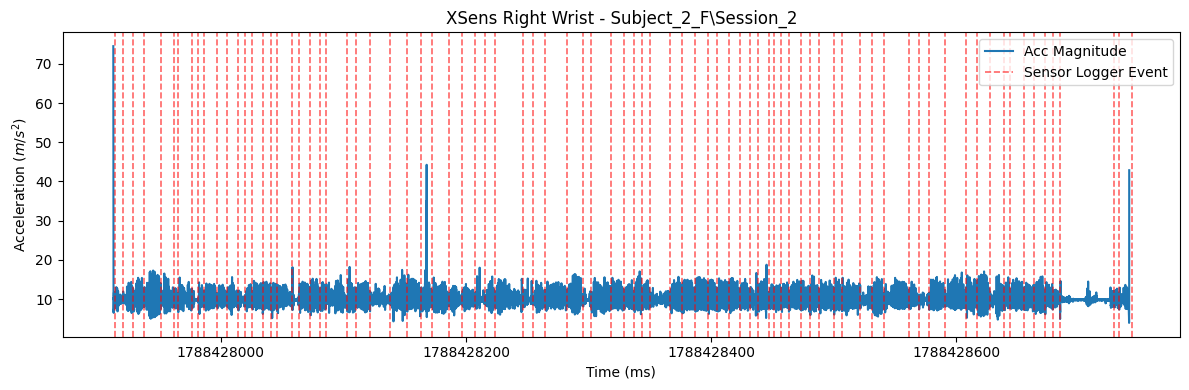

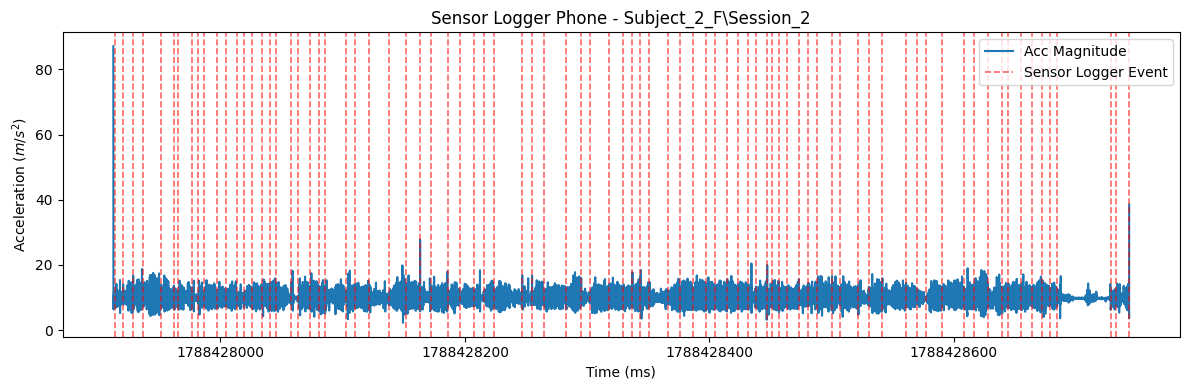

lenth of the right sensor 43186
Starting and ending seconds of XSens 0.0  to  719.75
Index(['time', 'Checkpoint', 'zeros_1', 'zeros_2', 'zeros_3', 'time_s'], dtype='str')
Index(['z', 'y', 'x', 'time', 'Normalized_time_secs'], dtype='str')
lenth of the sensor logger 43388
Starting and ending seconds of Sensor Logger 0.0  to  723.116667


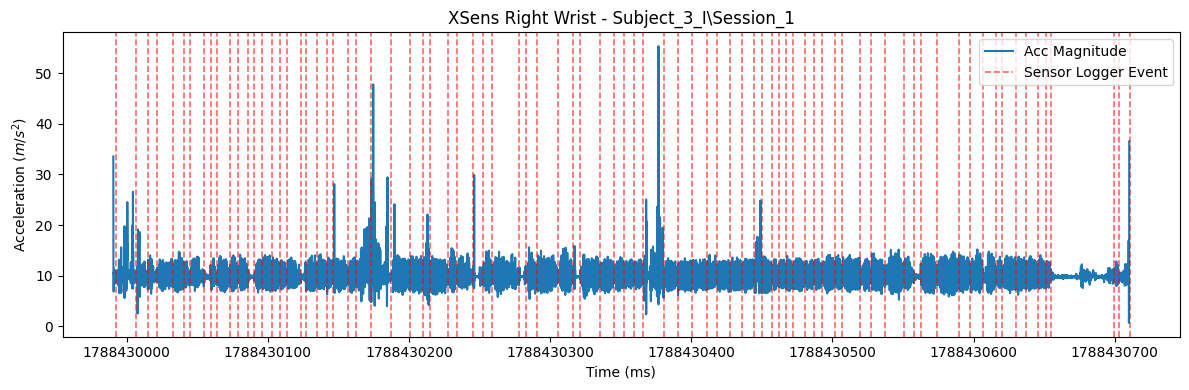

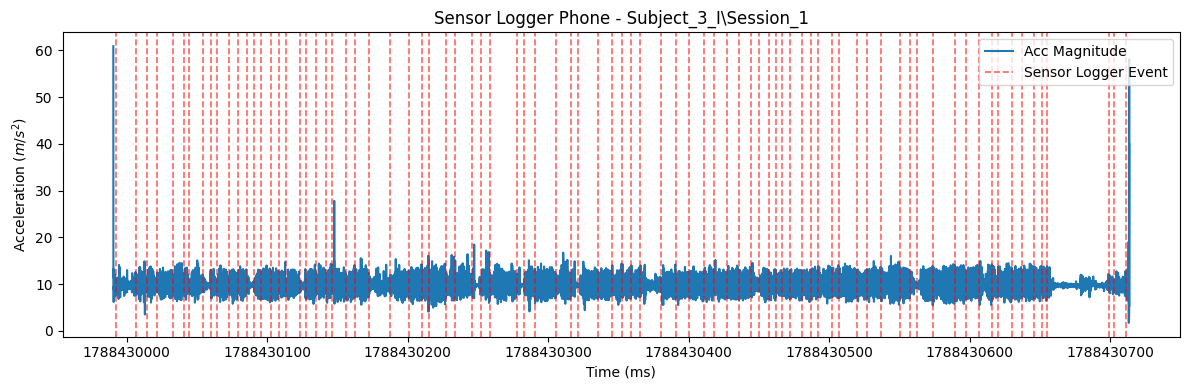

lenth of the right sensor 43151
Starting and ending seconds of XSens 0.0  to  719.166667
Index(['time', 'Checkpoint', 'zeros_1', 'zeros_2', 'zeros_3', 'time_s'], dtype='str')
Index(['z', 'y', 'x', 'time', 'Normalized_time_secs'], dtype='str')
lenth of the sensor logger 43356
Starting and ending seconds of Sensor Logger -0.0  to  722.583333


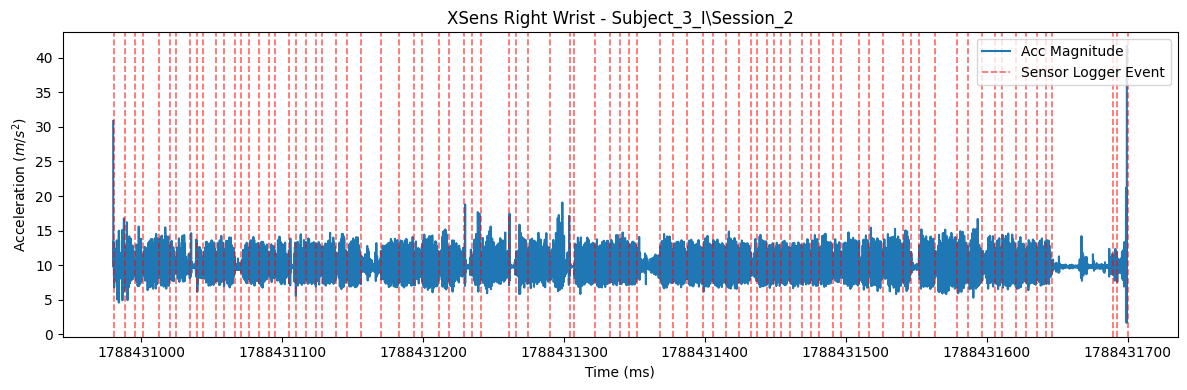

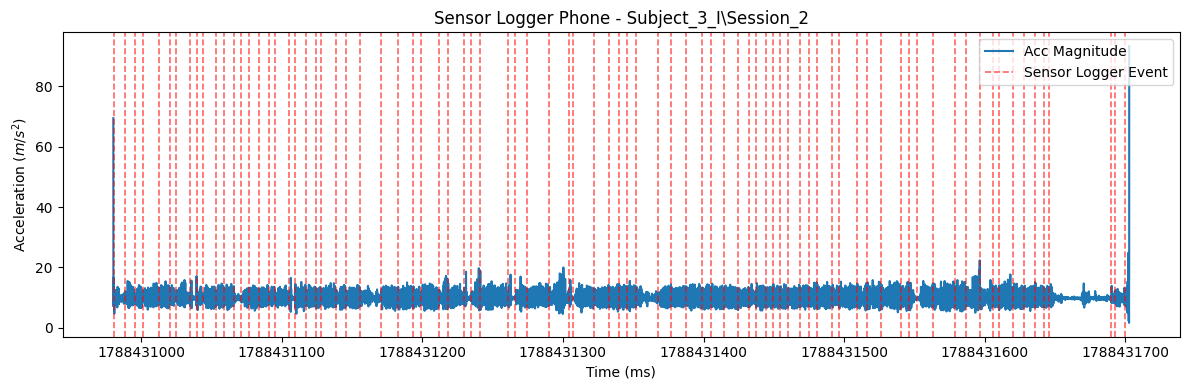

In [ ]:
for i in range(len(dir_file)):

    session = dir_file[i]

    # --------------------------------------------------
    # Load XSens right-wrist data
    # --------------------------------------------------
    right_wrist_path = (
        data_dir
        / session
        / config["xsens_folder"]["trimmed_folder"]
        / "trimmed_10B41710.csv"
    )

    right_wrist_df = src.data_loader.load_sensor_data(
        right_wrist_path
    )

    print("Length of the right wrist sensor:", len(right_wrist_df))
    print(
        "Starting and ending seconds of XSens:",
        right_wrist_df["Normalized_time_secs"].iloc[0],
        "to",
        right_wrist_df["Normalized_time_secs"].iloc[-1]
    )

    right_wrist_df["timestamp_s"] = (
        right_wrist_df["timestamp_ns"] / 1e9
    ).round(4)


    # --------------------------------------------------
    # Load Step Logger data
    # --------------------------------------------------
    step_logger_path = (
        data_dir
        / session
        / "Step_logger"
        / "buttonsPressed.csv"
    )

    step_logger_df = src.data_loader.load_sensor_data(
        step_logger_path
    )


    # --------------------------------------------------
    # Load Sensor Logger data
    # --------------------------------------------------
    sensor_logger_path = (
        data_dir
        / session
        / Sensor_Logger_folder
        / config["sensor_logger"]["trimmed_60Hz_folder"]
        / f"{trimmed_sensor_logger_file_prefix}.csv"
    )

    sensor_logger_df = src.data_loader.load_sensor_data(
        sensor_logger_path
    )

    print("Length of the Sensor Logger:", len(sensor_logger_df))
    print(
        "Starting and ending seconds of Sensor Logger:",
        sensor_logger_df["Normalized_time_secs"].iloc[0],
        "to",
        sensor_logger_df["Normalized_time_secs"].iloc[-1]
    )

    sensor_logger_df["timestamp_s"] = (
        sensor_logger_df["time"] / 1e9
    ).round(4)


    # --------------------------------------------------
    # Calculate acceleration magnitude
    # --------------------------------------------------
    acc_mag_right_wrist = np.sqrt(
        right_wrist_df["Acc_X"]**2
        + right_wrist_df["Acc_Y"]**2
        + right_wrist_df["Acc_Z"]**2
    )

    acc_mag_sensor_logger = np.sqrt(
        sensor_logger_df["x"]**2
        + sensor_logger_df["y"]**2
        + sensor_logger_df["z"]**2
    )


    # --------------------------------------------------
    # Plot XSens with Step Logger checkpoints
    # --------------------------------------------------
    src.visualisation.plot_acceleration_magnitude_with_checkpoints(
        step_logger_df,
        right_wrist_df["timestamp_s"],
        acc_mag_right_wrist,
        f"XSens Right Wrist - {session}"
    )


    # --------------------------------------------------
    # Plot Sensor Logger with Step Logger checkpoints
    # --------------------------------------------------
    src.visualisation.plot_acceleration_magnitude_with_checkpoints(
        step_logger_df,
        sensor_logger_df["timestamp_s"],
        acc_mag_sensor_logger,
        f"Sensor Logger Phone - {session}"
    )